## Task 1 – Pregunta 1.1

### 1. ¿Qué es Data Augmentation y por qué no son datos falsos?

El **Data Augmentation** es una técnica que consiste en generar nuevas versiones de las imágenes existentes aplicando pequeñas transformaciones (como rotaciones leves, cambios de brillo o recortes), sin alterar el contenido clínico relevante.(s.f, 2024)

**Analogía para el médico:**

Un paciente al que se observa en diferentes condiciones:
- con distinta iluminación,
- en una posición ligeramente diferente,
- o con variaciones normales del equipo de rayos X.

El paciente sigue siendo el mismo, y su diagnóstico no cambia.  
Lo único que cambia es **cómo se ve la imagen**, no **lo que contiene clínicamente**.

Por eso, **no estamos inventando datos falsos**, sino mostrando al modelo las mismas radiografías en condiciones ligeramente distintas, tal como ocurriría en la práctica real en clínicas rurales.

Esto ayuda a que el modelo no “memorice” una imagen específica, sino que aprenda **patrones generales de enfermedad**.

---

### 2. Transformaciones válidas en radiografías de tórax

A continuación, tres transformaciones apropiadas para este dominio:

#### a) Rotaciones leves ($$\pm 5^grados$$ a $$\pm 10^grados$$)
- **Justificación:** En la práctica, los pacientes no siempre están perfectamente alineados.
- **Impacto positivo:** El modelo aprende a reconocer anomalías aunque la imagen esté ligeramente inclinada.

---

#### b) Ajustes de brillo y contraste
- **Justificación:** Diferentes equipos de rayos X o condiciones de exposición generan imágenes más claras u oscuras.
- **Impacto positivo:** Mejora la robustez del modelo ante variabilidad entre clínicas rurales.

---

#### c) Traslaciones o recortes leves (shifts)
- **Justificación:** El encuadre del tórax puede variar dependiendo del técnico.
- **Impacto positivo:** El modelo no depende de que los pulmones estén exactamente centrados.

---

### Transformación NO recomendada

#### d) Volteo horizontal (horizontal flip)
- **Problema:** Invierte izquierda y derecha del cuerpo.
- **Riesgo clínico:** Puede alterar información anatómica crítica (por ejemplo, ubicación de lesiones o del corazón).
- **Consecuencia:** El modelo podría aprender patrones incorrectos y comprometer la interpretación médica.

---

### 3. ¿Es suficiente el Data Augmentation?

No, **el Data Augmentation por sí solo no garantiza una buena generalización**.

Es una herramienta que puede ayudar bastante, pero debe complementarse:

#### a) Calidad y representatividad del dataset
- 800 imágenes pueden ser insuficientes si no cubren **diversidad** (edades, equipos, condiciones clínicas).
- “Garbage in, garbage out”: el modelo solo puede aprender lo que ve.

---

#### b) Uso de Transfer Learning
- Utilizar modelos preentrenados (por ejemplo, en ImageNet o datasets médicos).
- Permite aprovechar conocimiento previo y reducir el riesgo de sobreajuste.

---

#### c) Regularización
Ejemplos:
- Dropout  
- Weight decay  

Estas técnicas ayudan a evitar que el modelo memorice:

$$
L = L_{datos} + \lambda ||w||^2
$$

---

#### d) Validación adecuada
- Separar correctamente entrenamiento, validación y prueba.
- Idealmente incluir datos de diferentes clínicas.

---

#### e) Arquitectura del modelo
- Dado que el sistema debe correr **sin GPU**, se requieren modelos livianos (por ejemplo, MobileNet, como transfer o primer modelo).
- Un modelo muy grande se puede sobreajustar con pocos datos.


## Task 1 – Pregunta 1.2

### 4. ¿Cuándo comienza el sobreajuste (overfitting)?

El sobreajuste comienza aproximadamente **después de la época 10 (alrededor de la 15)**.

- Hasta la época 10: ambas pérdidas **disminuyen**, lo cual indica buen aprendizaje.
- A partir de la época 15 porque la **loss de validación empieza a subir** (0.38 → 0.89)

Esto indica que el modelo está **memorizando el dataset de entrenamiento** pero perdiendo capacidad de generalizar a nuevos datos.

### 5. Estrategias de regularización

#### a) Dropout

**Idea:** Durante el entrenamiento, se "apagan" aleatoriamente neuronas con cierta probabilidad.

**Intuición matemática:**
- Evita que el modelo dependa demasiado de combinaciones específicas de neuronas.
- Reduce la co-adaptación de características.

En términos simples, el modelo deja de aprender patrones demasiado específicos.

**Impacto esperado en las curvas:**
- La loss de entrenamiento subiría ligeramente (entrenamiento más difícil).
- La loss de validación disminuiría o se estabilizaría.
- Se reduciría la brecha entre ambas curvas.


#### b) Regularización L2 (Weight Decay)

Penaliza pesos grandes en el modelo.

$$
L = L_{datos} + \lambda ||w||^2
$$

- Obliga al modelo a mantener pesos pequeños.
- Evita funciones demasiado complejas o altamente ajustadas al ruido.

Por lo tanto:
- La loss de entrenamiento no bajaría tan agresivamente.
- La loss de validación dejaría de crecer tan rápido.
- Curvas más suaves y cercanas entre sí.


### 6. Riesgo médico del sobreajuste

Desde una perspectiva médica, este patrón es **especialmente peligroso** por varias razones:

#### a) Falsa sensación de precisión
El modelo parece muy bueno en entrenamiento (loss muy baja), pero en realidad:
- Puede fallar en pacientes reales.
- No generaliza a nuevas clínicas o equipos.


#### b) Diagnósticos incorrectos
- **Falsos negativos:** no detectar neumonía → paciente sin tratamiento.
- **Falsos positivos:** diagnosticar enfermedad inexistente → tratamientos innecesarios.

En ambos casos hay consecuencias sumamente graves.


#### c) Variabilidad en clínicas rurales
El modelo se usará en entornos con:
- diferentes máquinas de rayos X,
- distintas condiciones de adquisición


#### d) Impacto en la confianza del sistema
Si los médicos notan errores inconsistentes:
- perderán confianza en la herramienta,
- lo cual compromete la adopción del sistema MediScan.


## Task 1 – Pregunta 1.3

### 7. Accuracy de un modelo naive

El dataset de prueba contiene:
- 700 imágenes **Normales**
- 150 imágenes con **Neumonía**
- Total: 850 imágenes

Un modelo naive que siempre predice **"Normal"**:
- Acierta las 700 imágenes normales
- Falla las 150 con neumonía

$$
Accuracy = \frac{700}{850} \approx 0.8235 \approx 82.35\%
$$

- Un modelo extremadamente simple logra **82.35% de accuracy** sin detectar ningún caso de neumonía.
- El 94% reportado es solo ~12% mejor que este baseline trivial.

Esto revela que el **accuracy puede ser engañoso** en datasets desbalanceados.

---

### 8. Métricas más informativas en contexto médico

En problemas médicos, el objetivo no es solo atinarle, sino **detectar correctamente y constantemente la enfermedad**.

#### a) Sensibilidad (Recall para neumonía)

$$
Recall = \frac{TP}{TP + FN}
$$

- Mide qué proporción de pacientes con neumonía fue correctamente detectada.
- **Relevancia clínica:**  
  Un bajo recall implica muchos **falsos negativos**, es decir, pacientes enfermos no diagnosticados.

En medicina, esto puede significar **no tratar a un paciente que lo necesita e incluso exponerlos a sugestionses**.

---

#### b) F1-Score

$$
F1 = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}
$$

- Balancea precisión (evitar falsos positivos) y recall (evitar falsos negativos).
- **Relevancia clínica:**
  - Penaliza modelos que solo optimizan una métrica.
  - Refleja mejor el desempeño real en escenarios desbalanceados.

---

### ¿Por qué son mejores que accuracy?

- El **accuracy está dominado por la clase mayoritaria** (normales).
- Un modelo puede tener alta accuracy y aún así:
  - fallar en detectar neumonía,
  - ser clínicamente inútil.

En este contexto, **detectar correctamente la enfermedad es más importante que acertar casos normales**.+

**Al final puede ser un clásico ejemplo de accuracy vs precision, pero ahora es mas delicado por el área de evaluación.**

---

### 9. Respuesta al inversionista

Un 94% de accuracy es un buen indicador inicial, pero no es suficiente por sí solo para evaluar la confiabilidad del modelo en un contexto médico. Nuestro dataset está desbalanceado, lo que significa que un modelo puede obtener alta precisión sin necesariamente detectar bien los casos de neumonía, que son los más críticos. Por eso, también evaluamos métricas como la sensibilidad y el F1-score, que reflejan mejor la capacidad del sistema para identificar pacientes enfermos. Nuestro enfoque es asegurar no solo un buen desempeño global, sino también minimizar errores clínicamente riesgosos antes de cualquier despliegue.

# Task 2

## Pregunta 2.1

### 1. ¿Se está de acuerdo con el desarrollador?

No se está de acuerdo con la afirmación de que **no tiene sentido usar Transfer Learning desde ImageNet** solo porque las radiografías son distintas a las imágenes naturales. Esa conclusión parte de una idea incompleta de lo que aprende una CNN en sus primeras capas.

Las **capas convolucionales tempranas** de una red no aprenden primero “perros”, “gatos” o “autos” como conceptos completos. Lo que realmente aprenden son **patrones visuales básicos y universales**, por ejemplo:

- bordes
- líneas
- gradientes de intensidad
- esquinas
- texturas simples
- transiciones entre regiones claras y oscuras

Ese tipo de patrones aparece también en radiografías, aunque estas sean en escala de grises y pertenezcan a un dominio médico. Una radiografía sigue siendo una imagen compuesta por contornos, contrastes, estructuras, densidades y formas. Por eso, el conocimiento de bajo nivel aprendido en ImageNet **sí puede transferirse**, incluso entre dominios visualmente distintos.

Lo que cambia más entre dominios suele ser lo que aprenden las **capas profundas**. En esas capas, la red empieza a combinar rasgos simples para formar representaciones más específicas del problema original. Allí sí puede haber una diferencia fuerte entre reconocer objetos naturales y detectar hallazgos médicos. Precisamente por eso el Fine-Tuning existe: permite **conservar lo que sí es útil** y **adaptar lo que debe especializarse**.

En consecuencia, entrenar desde cero “para no contaminar” no es, en este caso, la mejor lógica. Más bien, usar una red preentrenada da una base visual inicial sólida y luego se ajusta al dominio médico con cuidado.

---

### 2. ¿Cuál es el costo real de entrenar desde cero para una startup como MediScan Guatemala?

El costo real de entrenar desde cero no se limita al uso de GPU o al tiempo de cómputo. Para una startup como MediScan Guatemala, hay varias dimensiones críticas.

#### a) Tiempo al mercado

Entrenar desde cero implica partir sin conocimiento previo. Eso normalmente requiere más ciclos de experimentación, más iteraciones de arquitectura, más ajustes de hiperparámetros y más tiempo para lograr un rendimiento aceptable. Para una startup, esto retrasa:

- la validación del producto
- las pruebas con hospitales
- la entrada al mercado
- la posibilidad de conseguir clientes o inversión

En un entorno real, llegar tarde puede ser tan costoso como tener un modelo técnicamente imperfecto.

#### b) Riesgo de desempeño y fracaso del proyecto

Con solo 800 imágenes, entrenar desde cero eleva mucho el riesgo de que el modelo:

- no converja bien
- aprenda patrones poco robustos
- sobreajuste rápidamente
- tenga mala generalización clínica

Eso significa invertir tiempo y recursos en una estrategia con alta probabilidad de fallar o producir un sistema poco confiable.

#### c) Talento humano especializado

Entrenar desde cero exige más experiencia técnica. No solo se necesita saber usar una CNN, sino también:

- diseñar o seleccionar una arquitectura adecuada
- manejar estrategias avanzadas de regularización
- controlar inestabilidad en el entrenamiento
- diagnosticar fallas complejas del modelo

Una startup normalmente trabaja con equipos pequeños y presupuestos ajustados. Por tanto, una estrategia que dependa menos de investigación profunda y más de buenas prácticas comprobadas suele ser más realista.

#### d) Costo de oportunidad

Mientras el equipo intenta hacer funcionar un entrenamiento desde cero, deja de invertir energía en otras áreas clave del producto, como:

- recolección de datos de mejor calidad
- validación clínica
- experiencia de usuario
- integración con hospitales
- cumplimiento regulatorio

En una startup, el recurso más escaso no siempre es la computación; muchas veces es la atención del equipo.

---

### 3. ¿Existe un escenario legítimo en el que sí se consideraría entrenar desde cero?

Sí, sí existe, pero sería un escenario mucho más exigente que el descrito para MediScan Guatemala.

Se consideraría entrenar desde cero si se cumplieran condiciones como las siguientes:

#### a) Existencia de un dataset médico masivo y representativo

Si se contara con decenas o cientos de miles de imágenes médicas bien etiquetadas, suficientemente diversas y cercanas al entorno clínico real, entrenar desde cero podría ser razonable. En ese caso, el modelo tendría suficiente evidencia para aprender directamente patrones propios del dominio sin depender tanto de representaciones heredadas.

#### b) Dominio extremadamente especializado y muy lejano al preentrenamiento original

Si el tipo de imagen fuera tan distinto que incluso los patrones iniciales de ImageNet resultaran poco útiles, podría evaluarse un entrenamiento desde cero. Esto podría pasar en modalidades muy particulares, como ciertas imágenes científicas o médicas altamente estructuradas, donde la distribución visual y las señales relevantes difieren radicalmente de imágenes naturales.

#### c) Disponibilidad de infraestructura, tiempo y equipo experto

También sería más defendible si la organización tuviera:

- gran capacidad de cómputo
- tiempo amplio de investigación
- personal especializado en visión por computadora médica
- procesos robustos de validación

En resumen, **sí hay escenarios legítimos**, pero no corresponden al contexto de una startup con 800 imágenes. En ese caso, la estrategia más sensata sigue siendo aprovechar Transfer Learning.

---

## Pregunta 2.2

### 4. ¿Qué opción se recomendaría y por qué?

Con un dataset médico de **800 imágenes** y un dominio distinto a ImageNet, no se recomendaría una versión extrema de ninguna de las dos opciones como solución definitiva. Sin embargo, entre las alternativas planteadas, la recomendación inicial se inclina más hacia **la Opción A** como punto de partida más seguro.

La lógica es la siguiente:

- el dataset es pequeño
- el riesgo de sobreajuste es alto
- las características generales de las primeras capas siguen siendo útiles
- actualizar toda la red con tan pocos datos puede destruir información valiosa ya aprendida

Congelar la red base al inicio permite usar la red preentrenada como extractor de características y entrenar primero el cabezal final para adaptar la salida al problema específico. Esto reduce la cantidad de parámetros que deben ajustarse con pocos datos y hace el entrenamiento más estable.

Ahora bien, en un caso real, lo ideal no sería quedarse permanentemente con toda la base congelada. La estrategia más razonable sería:

1. entrenar primero el cabezal con la base congelada  
2. luego descongelar solo las últimas capas del backbone  
3. aplicar Fine-Tuning gradual con una tasa de aprendizaje pequeña  

Eso no aparece exactamente como una de las dos opciones, pero es la lógica que mejor encaja con este caso concreto.

Entonces, si hubiera que escoger estrictamente entre A y B, se elegiría **A al inicio**, porque es menos riesgosa para un dataset pequeño. La razón no es una “regla de oro” memorizada, sino que con pocos datos conviene **proteger el conocimiento general ya aprendido** y evitar cambios bruscos en toda la red.

---

### 5. ¿Qué riesgo específico habría si se aplica la Opción B con una tasa de aprendizaje alta en toda la red?

Si se descongela toda la red y se usa una tasa de aprendizaje alta como **1e-3** en todas las capas, el riesgo principal es destruir rápidamente las representaciones útiles que el modelo había aprendido durante el preentrenamiento.

Ese fenómeno se conoce como **catastrophic forgetting** o **olvido catastrófico**.

Lo que ocurre es que los pesos cambian demasiado rápido en respuesta a un dataset pequeño y especializado. En lugar de adaptar cuidadosamente el conocimiento previo, la red lo sobrescribe de forma agresiva. Como consecuencia:

- se pierden características generales útiles
- el entrenamiento se vuelve inestable
- el modelo puede sobreajustarse al conjunto de entrenamiento
- la generalización en validación empeora

Durante el entrenamiento, esto podría evidenciarse de varias maneras:

- la pérdida de entrenamiento baja rápido, pero la de validación empeora
- la métrica de validación fluctúa mucho
- aparece una brecha grande entre entrenamiento y validación
- el modelo termina con buen desempeño aparente en train, pero pobre desempeño en datos nuevos

En otras palabras, la red “aprende” demasiado fuerte y demasiado rápido sobre un conjunto pequeño, sacrificando robustez.

---

### 6. Si MediScan Guatemala logra recolectar 50,000 radiografías etiquetadas, ¿cambiaría la recomendación?

Sí, la recomendación cambiaría de forma importante.

Con **50,000 radiografías etiquetadas**, el panorama es distinto porque ya existe suficiente información para ajustar una porción mucho mayor del modelo e incluso considerar una adaptación profunda del backbone.

En ese escenario, la estrategia podría evolucionar así:

#### Etapa inicial
Seguiría siendo útil arrancar desde pesos preentrenados, porque acelera la convergencia y ofrece una base sólida.

#### Etapa intermedia
Ya sería razonable descongelar más capas, especialmente las capas medias y profundas, para que la red aprenda representaciones más específicas del dominio radiológico.

#### Etapa avanzada
Con suficiente diversidad y calidad en el dataset, incluso podría considerarse entrenar una arquitectura desde cero o usar preentrenamiento sobre datos médicos en lugar de ImageNet, si el objetivo es maximizar desempeño clínico y se cuenta con recursos suficientes.

La razón del cambio es clara: cuando hay muchos más datos, el riesgo de sobreajuste disminuye y la red tiene más oportunidad de aprender patrones genuinamente propios del dominio. En ese contexto, mantener casi toda la red congelada podría volverse una limitación, porque impediría especializar suficientemente las representaciones internas.

Entonces, con 50,000 imágenes, la estrategia dejaría de ser conservadora y pasaría a ser un Fine-Tuning más profundo, progresivo y ambicioso.

---

## Pregunta 2.3

### 7. ¿Es viable reutilizar el modelo de neumonía para fracturas de muñeca?

Sí, **es viable reutilizar parte del modelo**, pero no sería correcto reutilizarlo directamente sin modificaciones ni validación. No hay que empezar completamente desde cero, pero tampoco se puede asumir que el mismo modelo funcionará igual para el nuevo problema.

La red puede analizarse por secciones:

#### a) Capas tempranas
Estas capas sí son bastante reutilizables, porque aprendieron patrones generales como bordes, contornos, texturas y contrastes. Esos elementos también aparecen en radiografías de muñeca.

#### b) Capas intermedias
Aquí puede haber cierto nivel de reutilización parcial. Estas capas combinan rasgos para detectar estructuras más complejas. Como siguen trabajando sobre imágenes radiográficas, parte del conocimiento puede ayudar, aunque ya empieza a depender más de la anatomía y del tipo de hallazgo.

#### c) Capas profundas y cabezal final
Estas son las partes que más habría que modificar. El modelo de neumonía fue optimizado para reconocer patrones pulmonares y señales asociadas al tórax, no líneas de fractura, discontinuidades óseas o alteraciones anatómicas en muñeca. Por ello, la parte final del modelo probablemente no sea adecuada tal como está.

En síntesis, **sí se puede aprovechar la base visual**, pero el cabezal de clasificación debe cambiarse y parte de las capas profundas debe readaptarse al nuevo dominio.

---

### 8. Plan de acción concreto de tres pasos para adaptar el modelo al nuevo dominio

#### Paso 1 - Reemplazar el cabezal final y entrenarlo primero

Se quitaría el cabezal entrenado para neumonía y se colocaría uno nuevo para el problema de fracturas de muñeca.  
Por ejemplo:

- una nueva capa fully connected
- salida binaria si solo se detecta fractura vs. no fractura
- o salida multiclase si se quieren varios tipos de hallazgo

En esta etapa:

- se congelaría todo el backbone
- se entrenaría solo el nuevo cabezal
- se usaría una tasa de aprendizaje relativamente mayor para el cabezal, por ejemplo **1e-3**

La razón es que el nuevo cabezal empieza desde cero y necesita aprender a mapear las características extraídas hacia la nueva tarea.

#### Paso 2 - Descongelar las últimas capas del backbone

Una vez que el cabezal ya responde razonablemente, se descongelarían solo las últimas capas del modelo base.

En esta etapa:

- se mantendrían congeladas las capas tempranas
- se descongelarían las capas profundas
- se usaría una tasa de aprendizaje pequeña, por ejemplo **1e-5** o **1e-4** en el backbone
- el cabezal podría mantenerse con una tasa un poco mayor que la base

La razón es permitir que las representaciones de alto nivel se adapten de neumonía en tórax a fracturas en muñeca sin destruir los filtros generales.

#### Paso 3 - Validar y ajustar progresivamente según resultados

Después del Fine-Tuning inicial, se evaluaría el desempeño en validación. Si el dataset de muñeca fuera suficientemente grande y estable, se podría descongelar una porción mayor de la red.

En esta etapa:

- se monitorizaría cuidadosamente overfitting
- se usarían técnicas como early stopping, data augmentation y regularización
- se calibraría el umbral de decisión clínico

La lógica es adaptar solo lo necesario y evitar cambios agresivos antes de tener evidencia de que mejoran el desempeño.

---

### 9. ¿Qué riesgo ético o clínico implica reutilizar un modelo de un dominio a otro sin validación rigurosa?

El riesgo ético y clínico es alto. Reutilizar un modelo entrenado para un problema médico distinto sin validación rigurosa puede generar decisiones erróneas que afecten directamente a pacientes.

Entre los riesgos principales están:

- **falsos negativos**, por ejemplo no detectar una fractura real
- **falsos positivos**, por ejemplo marcar como fractura una imagen sana
- confianza excesiva del personal clínico en un sistema no validado
- uso del modelo fuera del contexto para el que fue desarrollado

Esto no es solo un problema técnico. En salud, una predicción errónea puede traducirse en:

- retraso en tratamiento
- tratamiento innecesario
- aumento del riesgo para el paciente
- pérdida de confianza en la herramienta
- posibles implicaciones legales y regulatorias

#### Proceso mínimo de validación recomendado antes del despliegue

Antes de desplegar el sistema, como mínimo debería realizarse:

1. **Validación con un dataset independiente**  
   No basta con evaluar sobre entrenamiento o validación interna. Debe probarse en datos nuevos y representativos del entorno real.

2. **Revisión por expertos clínicos**  
   Radiólogos o especialistas deben revisar resultados, errores frecuentes y utilidad práctica del modelo.

3. **Evaluación con métricas clínicamente relevantes**  
   No solo accuracy. Deben analizarse métricas como:
   - sensibilidad
   - especificidad
   - precisión
   - F1
   - AUC
   - matriz de confusión

4. **Análisis de subgrupos**  
   Debe verificarse si el modelo falla más en ciertos tipos de pacientes, equipos radiológicos o condiciones de imagen.

5. **Prueba piloto controlada**  
   Antes del uso amplio, conviene implementarlo como sistema de apoyo, no como decisor autónomo, observando su comportamiento en práctica real.

La conclusión es que reutilizar un modelo médico en otro dominio sin validación rigurosa no solo sería un error metodológico, sino también una falta de responsabilidad clínica.



# Task 4

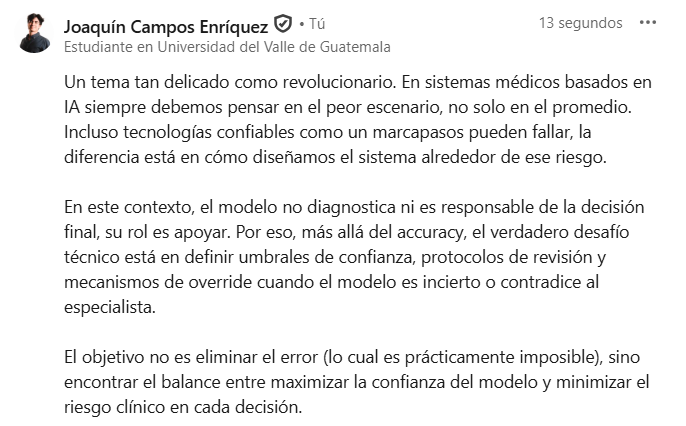